In [2]:
import pandas as pd
from sklearn.datasets import load_iris

iris_raw = load_iris()
iris_df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)

iris_df['species_id'] = iris_raw.target
species_mapping = {i: name for i, name in enumerate(iris_raw.target_names)}
iris_df['species_name'] = iris_df['species_id'].map(species_mapping)

print("Iris dimensions:", iris_df.shape)
print("Missing entries checking:\n", iris_df.isnull().sum())
print(iris_df.head(3))

for col in iris_raw.feature_names:
    mean_val = iris_df[col].mean()
    median_val = iris_df[col].median()
    mode_val = iris_df[col].mode()[0]
    print(f"Feature: {col}")
    print(f"  Mean:   {mean_val:.4f} cm")
    print(f"  Median: {median_val:.4f} cm")
    print(f"  Mode:   {mode_val:.4f} cm")
    print("-" * 40)

for col in iris_raw.feature_names:
    variance = iris_df[col].var()
    std_dev = iris_df[col].std()
    data_range = iris_df[col].max() - iris_df[col].min()
    q1 = iris_df[col].quantile(0.25)
    q3 = iris_df[col].quantile(0.75)
    print(f"Feature: {col}")
    print(f"  Variance:           {variance:.4f}")
    print(f"  Std Deviation:      {std_dev:.4f}")
    print(f"  Range (Max - Min):  {data_range:.4f}")
    print(f"  IQR (Q3 - Q1):      {q3 - q1:.4f}")
    print("-" * 40)

for col in iris_raw.feature_names:
    skewness = iris_df[col].skew()
    kurtosis = iris_df[col].kurt()
    print(f"Feature: {col}")
    print(f"  Skewness (Asymmetry): {skewness:.4f}")
    print(f"  Kurtosis (Tails):     {kurtosis:.4f}")
    print("-" * 40)

Iris dimensions: (150, 6)
Missing entries checking:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_id           0
species_name         0
dtype: int64
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  
Feature: sepal length (cm)
  Mean:   5.8433 cm
  Median: 5.8000 cm
  Mode:   5.0000 cm
----------------------------------------
Feature: sepal width (cm)
  Mean:   3.0573 cm
  Median: 3.0000 cm
  Mode:   3.0000 cm
----------------------------------------
Feature: petal length (cm)
  Mean:   3.7580 cm
  Median: 4.3500 cm
  Mode:   1.4000 cm
---------------------

In [3]:
grouped_species = iris_df.groupby('species_name')

print("--- Group-Wise Mean Values ---")
print(grouped_species[iris_raw.feature_names].mean())

print("\n--- Group-Wise Standard Deviation Profiles ---")
print(grouped_species[iris_raw.feature_names].std())


aggregated_stats = iris_df.groupby('species_name')['petal length (cm)'].agg(['mean', 'median', 'std', 'skew'])
print("Aggregated Statistics (Petal Length):\n", aggregated_stats)

--- Group-Wise Mean Values ---
              sepal length (cm)  sepal width (cm)  petal length (cm)  \
species_name                                                           
setosa                    5.006             3.428              1.462   
versicolor                5.936             2.770              4.260   
virginica                 6.588             2.974              5.552   

              petal width (cm)  
species_name                    
setosa                   0.246  
versicolor               1.326  
virginica                2.026  

--- Group-Wise Standard Deviation Profiles ---
              sepal length (cm)  sepal width (cm)  petal length (cm)  \
species_name                                                           
setosa                 0.352490          0.379064           0.173664   
versicolor             0.516171          0.313798           0.469911   
virginica              0.635880          0.322497           0.551895   

              petal width (cm)  
s

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


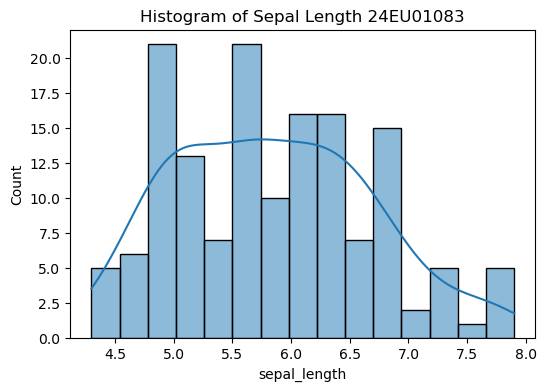

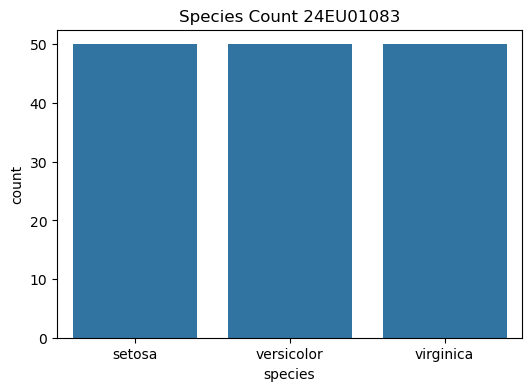

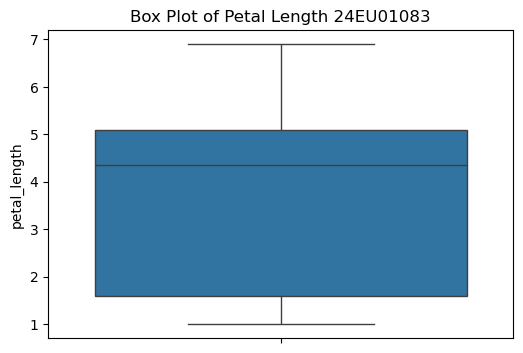

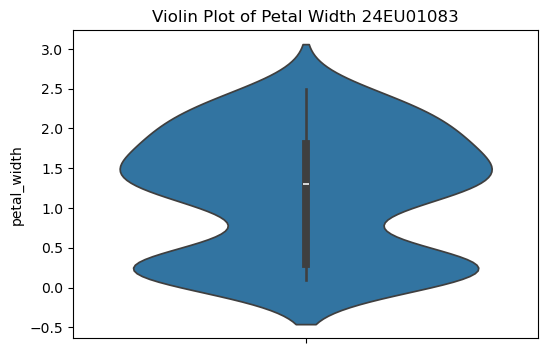

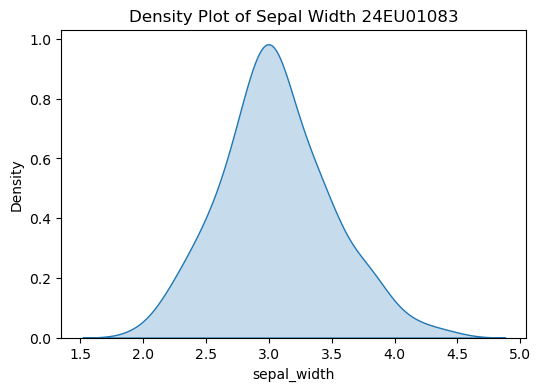

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df["sepal_length"], bins=15, kde=True)
plt.title("Histogram of Sepal Length 24EU01083")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="species", data=df)
plt.title("Species Count 24EU01083")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y="petal_length", data=df)
plt.title("Box Plot of Petal Length 24EU01083")
plt.show()

plt.figure(figsize=(6,4))
sns.violinplot(y="petal_width", data=df)
plt.title("Violin Plot of Petal Width 24EU01083")
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(df["sepal_width"], fill=True)
plt.title("Density Plot of Sepal Width 24EU01083")
plt.show()

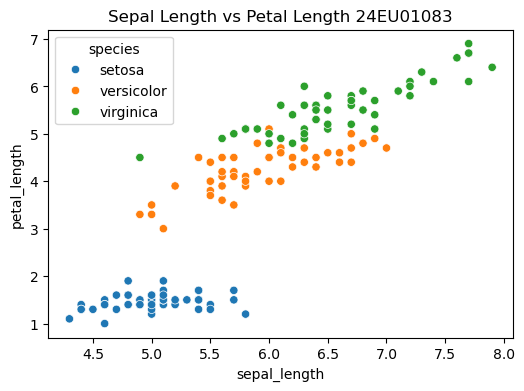

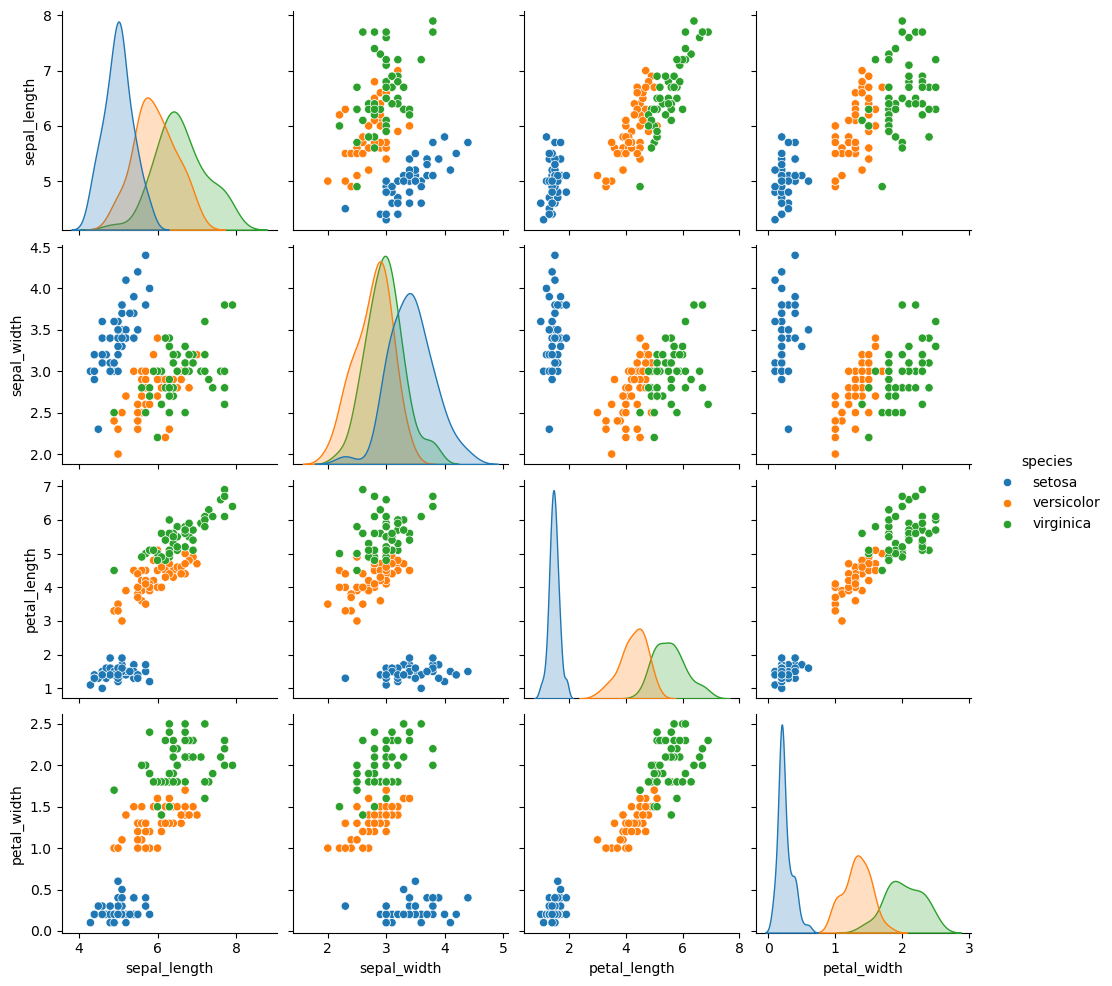

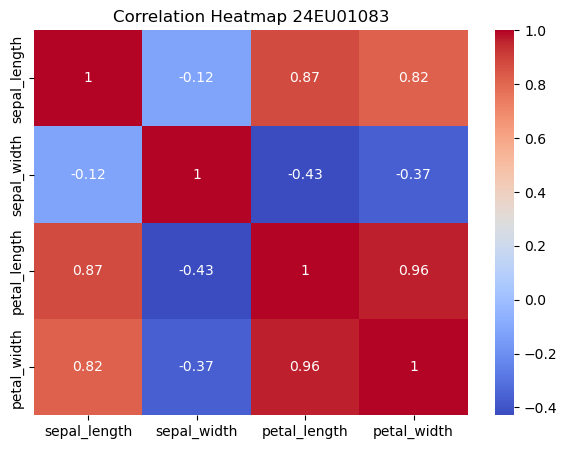

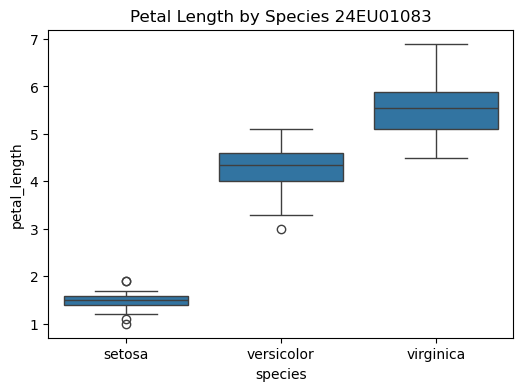

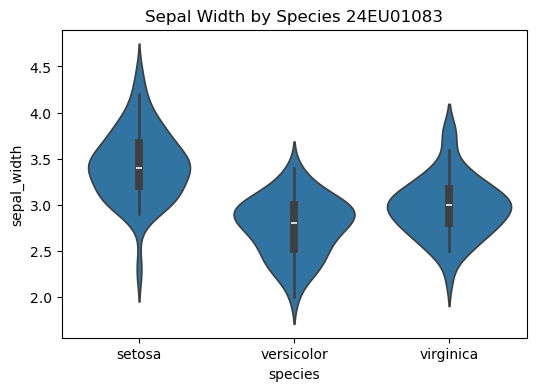

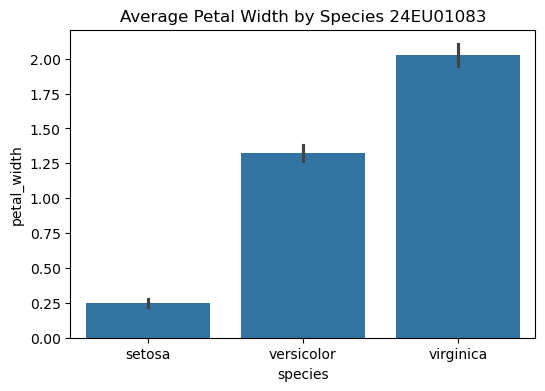

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="sepal_length", y="petal_length",
                hue="species", data=df)
plt.title("Sepal Length vs Petal Length 24EU01083")
plt.show()

sns.pairplot(df, hue="species")
plt.show()

plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap 24EU01083")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="species", y="petal_length", data=df)
plt.title("Petal Length by Species 24EU01083")
plt.show()

plt.figure(figsize=(6,4))
sns.violinplot(x="species", y="sepal_width", data=df)
plt.title("Sepal Width by Species 24EU01083")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x="species", y="petal_width", data=df)
plt.title("Average Petal Width by Species 24EU01083")
plt.show()

In [7]:
import pandas as pd
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
df = pd.read_csv(url, header=None)
df.rename(columns={60: "Target"}, inplace=True)
print(df.head())

        0       1       2       3       4       5       6       7       8  \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

        9  ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

       58      59  Target  
0  0.0090  0.0032       R  
1  0.0052  0.0044       R  
2  0.009

In [8]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nClass Distribution:")
print(df["Target"].value_counts())

Shape: (208, 61)

Data Types:
0         float64
1         float64
2         float64
3         float64
4         float64
           ...   
56        float64
57        float64
58        float64
59        float64
Target     object
Length: 61, dtype: object

Statistical Summary:
               0           1           2           3           4           5   \
count  208.000000  208.000000  208.000000  208.000000  208.000000  208.000000   
mean     0.029164    0.038437    0.043832    0.053892    0.075202    0.104570   
std      0.022991    0.032960    0.038428    0.046528    0.055552    0.059105   
min      0.001500    0.000600    0.001500    0.005800    0.006700    0.010200   
25%      0.013350    0.016450    0.018950    0.024375    0.038050    0.067025   
50%      0.022800    0.030800    0.034300    0.044050    0.062500    0.092150   
75%      0.035550    0.047950    0.057950    0.064500    0.100275    0.134125   
max      0.137100    0.233900    0.305900    0.426400    0.401000    0.38230

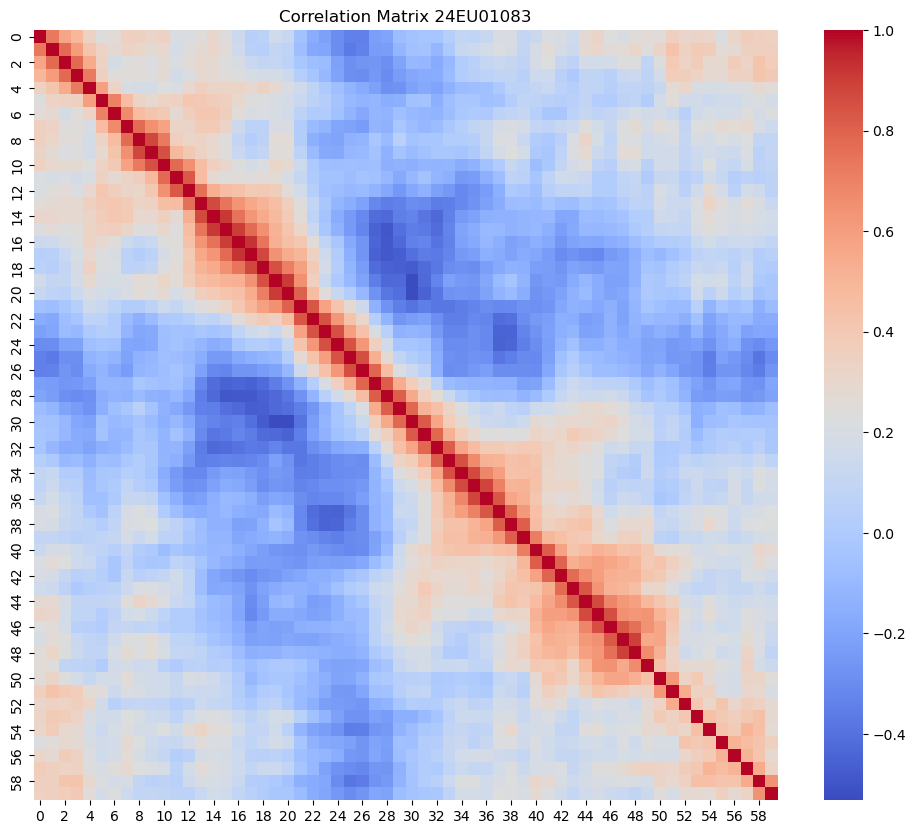

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.iloc[:, :-1].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix 24EU01083")
plt.show()

In [10]:
import sys
print(sys.executable)  
import numpy
print(numpy.__version__) 

C:\Users\Mahi\anaconda3\python.exe
2.3.5


In [11]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['Species'] = iris.target

df['Species'] = df['Species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

print("\n===== First 5 Rows =====")
print(df.head())

print("\n===== Last 5 Rows =====")
print(df.tail())

print("\n===== Dataset Shape =====")
print(df.shape)

print("\nRows :", df.shape[0])
print("Columns :", df.shape[1])

print("\n===== Column Names =====")
print(df.columns.tolist())

print("\n===== Data Types =====")
print(df.dtypes)

print("\n===== Dataset Information =====")
df.info()

print("\n===== Statistical Description =====")
print(df.describe())

print("\n===== Missing Values =====")
print(df.isnull().sum())

print("\n===== Duplicate Records =====")
print(df.duplicated().sum())

print("\n===== Random 5 Samples =====")
print(df.sample(5))

print("\n===== Unique Values =====")
print(df.nunique())

print("\n===== Species Distribution =====")
print(df['Species'].value_counts())


===== First 5 Rows =====
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  Setosa  
1  Setosa  
2  Setosa  
3  Setosa  
4  Setosa  

===== Last 5 Rows =====
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3 